# Sparseness Optimized Feature Importance

Sparseness Optimized Feature Importance (SOFI) is a model agnostic post hoc explainer. An explanation takes the form of a ranking of features, and its quality is the degradation score, namely the integral between two perturbation curves. The MoRF curve marginalizes the most relevant features first and should collapse immediately, while the LeRF curve marginalizes the least relevant ones first and should stay flat for as long as possible. Maximizing the gap rewards sparsity and correctness at once.

This notebook preesents four examples, each one complete from the loading of the data to the figures, and each one built on a dataset with more than 15 features. Between them they cover classification and regression, features that are mixed, purely nominal or purely numerical, and the four ways of telling the explainer how features map onto the columns the model consumes. Every example reports the whole set of metrics twice over, for the global explanation and for four individual instances.

| Example | Task | Features | Encoding |
| --- | --- | --- | --- |
| 1. Bank marketing | classification | 19, mixed | pipeline carrying the encoder |
| 2. Mushroom | classification | 21, only nominal | encoder passed apart |
| 3. Telecom charges | regression | 18, mixed | encoded data with feature groups |
| 4. College tuition | regression | 16, only numerical | model passed directly |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

from sofi import (
    SOFIExplainer,
    feature_groups_from_encoder,
    plot_explanation_grid,
    set_curve_colors,
    select_reliable_instances,
    set_plot_style,
)

RANDOM_STATE = 42
SELVA = "https://raw.githubusercontent.com/selva86/datasets/master/"
STEDY = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/"
TELCO = (
    "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/"
    "Telco-Customer-Churn.csv"
)

# the font size of every figure is fixed once and never touched again
set_plot_style(font_scale=1.15)

# the colour of the two curves is set here and holds for every figure below
set_curve_colors(morf="#03719c", lerf="#1E1A17")
pd.set_option("display.width", 130)

In this notebook, one helper serves every example. It explains the instances chosen for the instance level figures, each one with the marginalization variant it is paired with, then draws the four panels and prints the whole set of metrics for each of them.

In [2]:
def local_figure(selected, title):
    plot_explanation_grid(
        [(f"instance {index}, {label}", explanation) for index, label, explanation in selected],
        title=title, panel_size=(4.5, 3.5),
    )
    plt.show()
    for index, label, explanation in selected:
        print(f"=== instance {index}, {label} marginalization")
        print(explanation.summary())
        print()


def local_explanations(instances, explainers, validation, iterations=60):
    return [
        (index, label, explainers[label].explain(
            validation.loc[[index]], mode="local", max_iterations=iterations
        ))
        for index, label in instances
    ]

## Example 1: Bank marketing

This example concerns a classification problem described by 9 numerical and 10 nominal features, where the target says whether a client subscribed a term deposit. The call duration is dropped, as the documentation of the dataset advises, since it is known only after the outcome. The estimator is a pipeline that carries its own encoder, which is the recommended arrangement. Nothing about the encoding has to be declared, because features are perturbed in their original space and the encoder is applied afterwards, so a category is always replaced with another complete category. This approach is the cleanest way to generate explanations with encoded features.

In [3]:
bank = pd.read_csv(SELVA + "bank-full.csv", sep=";").drop(columns=["duration"])
bank_target = LabelEncoder().fit_transform(bank["y"])
bank_features = bank.drop(columns=["y"])

# a subsample keeps the notebook quick, the full file holds forty one thousand rows
keep = bank_features.sample(6000, random_state=RANDOM_STATE).index
bank_features, bank_target = bank_features.loc[keep], bank_target[keep]

bank_numeric = bank_features.select_dtypes(include="number").columns.tolist()
bank_nominal = [c for c in bank_features.columns if c not in bank_numeric]

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    bank_features, bank_target, test_size=0.25,
    random_state=RANDOM_STATE, stratify=bank_target,
)

bank_model = Pipeline(
    [
        (
            "encoder",
            ColumnTransformer(
                [
                    ("numeric", "passthrough", bank_numeric),
                    (
                        "nominal",
                        OneHotEncoder(drop="first", sparse_output=False, dtype=int, handle_unknown="ignore"),
                        bank_nominal,
                    ),
                ],
                verbose_feature_names_out=False,
            ),
        ),
        (
            "forest",
            RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, class_weight="balanced"),
        ),
    ]
)
bank_model.fit(Xb_train, yb_train)

print("features", bank_features.shape[1], "numerical", len(bank_numeric), "nominal", len(bank_nominal))
print("test accuracy", round(bank_model.score(Xb_test, yb_test), 3))

features 19 numerical 9 nominal 10
test accuracy 0.893


The premise of our dclarative explainer is that the response deteriorates as features are marginalized, which only holds for instances the model handles well, so the validation set is built outside the explainer. It is worth mentioning that the marginalization values come from the training data alone. The background variant averages the response over a fixed sample of training rows, which approximates the expectation the method is defined on, and it is the default setting.

In [4]:
bank_correct, correct = select_reliable_instances(
    bank_model, Xb_test, yb_test, return_mask=True
)
bank_labels = yb_test[correct]

# the two decisions are drawn in equal number. Subscribers are a small minority of this
# dataset, so a validation set that follows the raw mix would hold almost only clients
# whose answer the model already knows before reading a single feature
generator = np.random.default_rng(RANDOM_STATE)
positions = np.concatenate([
    generator.choice(np.flatnonzero(bank_labels == value), 30, replace=False)
    for value in (0, 1)
])
bank_validation = bank_correct.iloc[np.sort(positions)]
print("validation instances", len(bank_validation), "per class", np.bincount(bank_model.predict(bank_validation)))

bank_explainer = SOFIExplainer(
    bank_model, Xb_train, marginalization="background", n_background=10,
    initialization="greedy", max_iterations=120, patience=40, n_restarts=1,
    random_state=RANDOM_STATE, verbose=False,
)
bank_global = bank_explainer.explain(bank_validation, mode="global")
print(bank_global.summary())

validation instances 60 per class [30 30]
SOFI explanation
  task                      classification
  mode                      global
  instances                 60
  features                  19
  degradation score         0.5522
  area under MoRF           0.1285
  area under LeRF           0.6807
  unperturbed probability   0.8164
  noise region              none detected
  search                    120 iterations, 0 restarts, 116 evaluations, 235 model queries
  ranking                   1. euribor3m, 2. nr.employed, 3. pdays, 4. poutcome, 5. emp.var.rate, 6. cons.conf.idx, 7. cons.price.idx, 8. month, 9. day_of_week, 10. job, 11. age, 12. previous, 13. education, 14. campaign, 15. contact, 16. housing, 17. marital, 18. default, 19. loan


C:\Users\20214772\AppData\Local\Temp\ipykernel_13280\3882099881.py:2: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


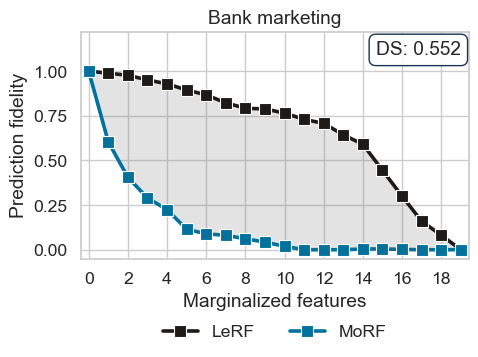

In [5]:
ax = bank_global.plot(figsize=(5.0, 4.0), title="Bank marketing")
plt.tight_layout()
plt.show()

The local mode runs one search per instance, so a decision receives its own ranking. The four
instances below were chosen among 12 candidates for disagreeing as much as possible with
the global ranking and with one another, and they alternate the two marginalization variants.

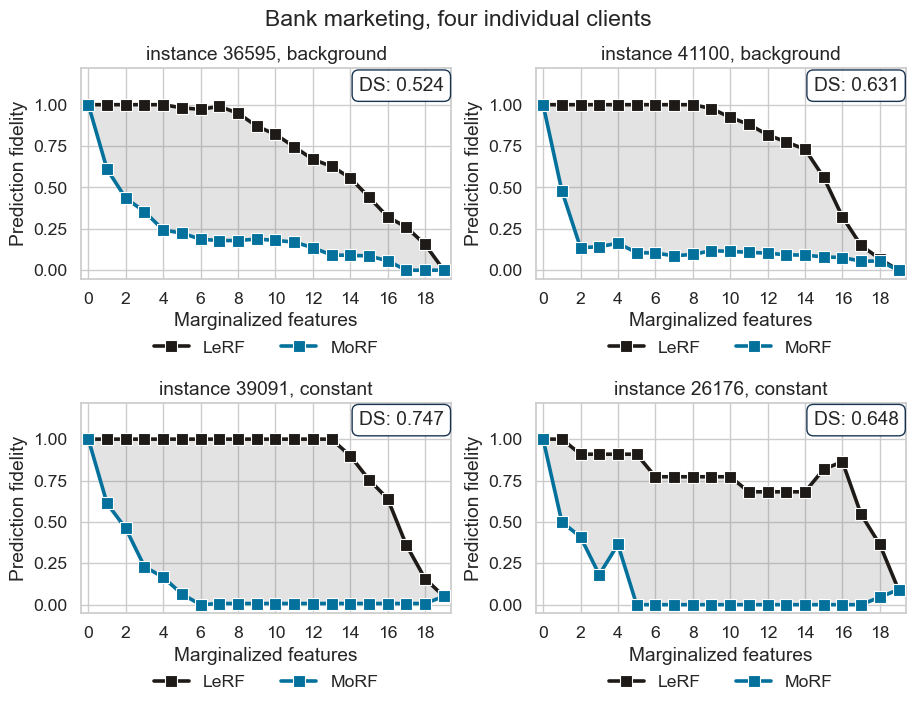

=== instance 36595, background marginalization
SOFI explanation
  task                      classification
  mode                      local
  instances                 1
  features                  19
  degradation score         0.5237
  area under MoRF           0.2060
  area under LeRF           0.7297
  unperturbed probability   0.6100
  noise region              none detected
  search                    60 iterations, 0 restarts, 58 evaluations, 119 model queries
  ranking                   1. euribor3m, 2. nr.employed, 3. education, 4. emp.var.rate, 5. job, 6. cons.price.idx, 7. previous, 8. contact, 9. campaign, 10. poutcome, 11. cons.conf.idx, 12. month, 13. age, 14. loan, 15. default, 16. marital, 17. day_of_week, 18. pdays, 19. housing

=== instance 41100, background marginalization
SOFI explanation
  task                      classification
  mode                      local
  instances                 1
  features                  19
  degradation score         0.6314
  area

In [6]:
bank_constant = SOFIExplainer(
    bank_model, Xb_train, marginalization="constant",
    max_iterations=120, patience=40, random_state=RANDOM_STATE, verbose=False,
)

bank_instances = [
    (36595, "background"),
    (41100, "background"),
    (39091, "constant"),
    (26176, "constant"),
]
bank_selected = local_explanations(
    bank_instances,
    {"background": bank_explainer, "constant": bank_constant},
    bank_validation,
)
local_figure(bank_selected, "Bank marketing, four individual clients")

## Example 2: Mushroom

It concerns a pattern classification problem defined by 21 nominal attributes and nothing else, where the target separates edible from poisonous specimens. The estimator was trained on the encoded matrix and cannot be wrapped, so the fitted encoder travels beside it. In this example, the SOFI explainer still perturbs whole features in their original space and applies the encoder before every query, which retains the integrity of each one-hot block keeping them indivisible.

In [7]:
mushroom = pd.read_csv(STEDY + "mushrooms.csv").drop(columns=["veil_type"])
mushroom_target = LabelEncoder().fit_transform(mushroom["type"])
mushroom_features = mushroom.drop(columns=["type"])
mushroom_nominal = mushroom_features.columns.tolist()

Xm_train, Xm_test, ym_train, ym_test = train_test_split(
    mushroom_features, mushroom_target, test_size=0.25,
    random_state=RANDOM_STATE, stratify=mushroom_target,
)

mushroom_encoder = ColumnTransformer(
    [("nominal", OneHotEncoder(drop="first", sparse_output=False, dtype=int), mushroom_nominal)],
    verbose_feature_names_out=False,
).fit(Xm_train)
mushroom_names = mushroom_encoder.get_feature_names_out()

mushroom_model = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
mushroom_model.fit(
    pd.DataFrame(mushroom_encoder.transform(Xm_train), columns=mushroom_names), ym_train
)
Xm_test_encoded = pd.DataFrame(mushroom_encoder.transform(Xm_test), columns=mushroom_names)

print("instances", len(mushroom), "nominal features", len(mushroom_nominal))
print("encoded columns", len(mushroom_names))
print("test accuracy", round(mushroom_model.score(Xm_test_encoded, ym_test), 3))

instances 8124 nominal features 21
encoded columns 95
test accuracy 1.0


In [8]:
mushroom_validation, correct = select_reliable_instances(
    mushroom_model, Xm_test, ym_test, encoder=mushroom_encoder, return_mask=True
)
mushroom_target_validation = ym_test[correct]
positions = np.sort(
    np.random.default_rng(RANDOM_STATE).choice(len(mushroom_validation), 60, replace=False)
)
mushroom_validation = mushroom_validation.iloc[positions]
mushroom_target_validation = mushroom_target_validation[positions]

mushroom_explainer = SOFIExplainer(
    mushroom_model, Xm_train, encoder=mushroom_encoder,
    marginalization="background", n_background=10,
    max_iterations=120, patience=40, n_restarts=1,
    random_state=RANDOM_STATE, verbose=False,
)
mushroom_global = mushroom_explainer.explain(mushroom_validation, mode="global")
print(mushroom_global.summary())

SOFI explanation
  task                      classification
  mode                      global
  instances                 60
  features                  21
  degradation score         0.5642
  area under MoRF           0.1355
  area under LeRF           0.6997
  unperturbed probability   0.9997
  noise region              none detected
  search                    120 iterations, 1 restarts, 115 evaluations, 233 model queries
  ranking                   1. odor, 2. spore_print_color, 3. gill_size, 4. stalk_root, 5. ring_type, 6. population, 7. bruises, 8. stalk_surface_above_ring, 9. ring_number, 10. gill_color, 11. stalk_surface_below_ring, 12. habitat, 13. stalk_color_above_ring, 14. stalk_shape, 15. cap_color, 16. gill_spacing, 17. cap_surface, 18. stalk_color_below_ring, 19. cap_shape, 20. veil_color, 21. gill_attachment


C:\Users\20214772\AppData\Local\Temp\ipykernel_13280\3538601370.py:2: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


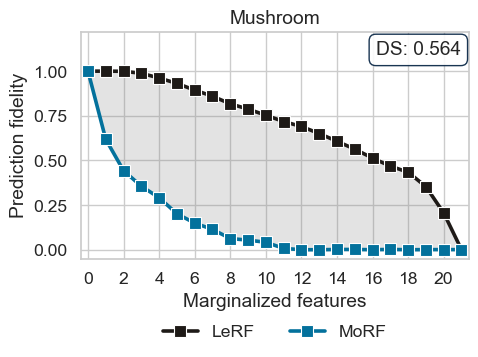

In [9]:
ax = mushroom_global.plot(figsize=(5.0, 4.0), title="Mushroom")
plt.tight_layout()
plt.show()

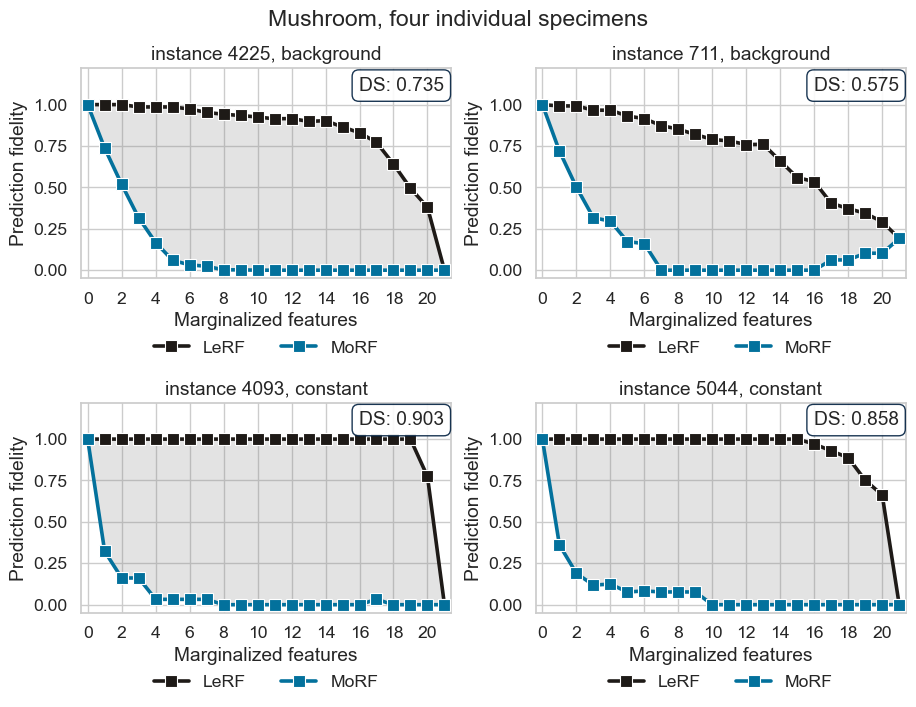

=== instance 4225, background marginalization
SOFI explanation
  task                      classification
  mode                      local
  instances                 1
  features                  21
  degradation score         0.7352
  area under MoRF           0.1123
  area under LeRF           0.8476
  unperturbed probability   1.0000
  noise region              none detected
  search                    60 iterations, 0 restarts, 60 evaluations, 123 model queries
  ranking                   1. odor, 2. ring_type, 3. stalk_surface_above_ring, 4. spore_print_color, 5. stalk_surface_below_ring, 6. bruises, 7. gill_spacing, 8. cap_color, 9. stalk_color_below_ring, 10. stalk_shape, 11. gill_color, 12. stalk_root, 13. habitat, 14. population, 15. gill_size, 16. stalk_color_above_ring, 17. gill_attachment, 18. cap_shape, 19. ring_number, 20. veil_color, 21. cap_surface

=== instance 711, background marginalization
SOFI explanation
  task                      classification
  mode         

In [10]:
mushroom_constant = SOFIExplainer(
    mushroom_model, Xm_train, encoder=mushroom_encoder, marginalization="constant",
    max_iterations=120, patience=40, random_state=RANDOM_STATE, verbose=False,
)

mushroom_instances = [
    (4225, "background"),
    (711, "background"),
    (4093, "constant"),
    (5044, "constant"),
]
mushroom_selected = local_explanations(
    mushroom_instances,
    {"background": mushroom_explainer, "constant": mushroom_constant},
    mushroom_validation,
)
local_figure(mushroom_selected, "Mushroom, four individual specimens")

## Example 3: Telecom charges

It concerns a regression task involving 16 nominal and two numerical attributes, where the target is the monthly charge of a subscriber. The data reaching the explainer is already encoded, so the blocks are declared through a mapping recovered from the fitted transformer. Marginalizing one column of a block in isolation would measure the role of a single category rather than the role of the feature, which is exactly what the mapping prevents.

A regressor is followed through the mean absolute deviation with respect to its own unperturbed estimate. The quantity grows as evidence is destroyed, so its negative plays the part the probability plays for a classifier, and the two settings share one reading.

In [11]:
telecom = pd.read_csv(TELCO).drop(columns=["customerID", "TotalCharges"])
telecom_target = telecom["MonthlyCharges"].astype(float)
telecom_features = telecom.drop(columns=["MonthlyCharges"])
telecom_numeric = telecom_features.select_dtypes(include="number").columns.tolist()
telecom_nominal = [c for c in telecom_features.columns if c not in telecom_numeric]

Xt_train, Xt_test, yt_train, yt_test = train_test_split(
    telecom_features, telecom_target, test_size=0.25, random_state=RANDOM_STATE
)

telecom_encoder = ColumnTransformer(
    [
        ("numeric", "passthrough", telecom_numeric),
        (
            "nominal",
            OneHotEncoder(drop="first", sparse_output=False, dtype=int, handle_unknown="ignore"),
            telecom_nominal,
        ),
    ],
    verbose_feature_names_out=False,
).fit(Xt_train)
telecom_names = telecom_encoder.get_feature_names_out()

Xt_train_encoded = pd.DataFrame(telecom_encoder.transform(Xt_train), columns=telecom_names)
Xt_test_encoded = pd.DataFrame(telecom_encoder.transform(Xt_test), columns=telecom_names)

telecom_model = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE)
telecom_model.fit(Xt_train_encoded, yt_train)

telecom_groups = feature_groups_from_encoder(telecom_encoder)
print("features", telecom_features.shape[1], "numerical", len(telecom_numeric), "nominal", len(telecom_nominal))
print("encoded columns", len(telecom_names), "block of InternetService", telecom_groups["InternetService"])
print("test coefficient of determination", round(telecom_model.score(Xt_test_encoded, yt_test), 3))

features 18 numerical 2 nominal 16
encoded columns 29 block of InternetService ['InternetService_Fiber optic', 'InternetService_No']
test coefficient of determination 0.998


In [12]:
telecom_validation = select_reliable_instances(
    telecom_model, Xt_test_encoded, yt_test, quantile=0.6
)
positions = np.sort(
    np.random.default_rng(RANDOM_STATE).choice(len(telecom_validation), 60, replace=False)
)
telecom_validation = telecom_validation.iloc[positions]
telecom_validation_target = yt_test.to_numpy()[telecom_validation.index]

telecom_explainer = SOFIExplainer(
    telecom_model, Xt_train_encoded, feature_groups=telecom_groups,
    marginalization="background", n_background=10,
    max_iterations=120, patience=40, n_restarts=1,
    random_state=RANDOM_STATE, verbose=False,
)
telecom_global = telecom_explainer.explain(telecom_validation, mode="global")
print(telecom_global.summary())

SOFI explanation
  task                   regression
  mode                   global
  instances              60
  features               18
  degradation score      0.7206
  area under MoRF        0.1104
  area under LeRF        0.8310
  unperturbed estimate   60.5212
  noise region           none detected
  search                 120 iterations, 1 restarts, 112 evaluations, 227 model queries
  ranking                1. InternetService, 2. StreamingTV, 3. StreamingMovies, 4. MultipleLines, 5. DeviceProtection, 6. TechSupport, 7. OnlineBackup, 8. OnlineSecurity, 9. PhoneService, 10. tenure, 11. PaymentMethod, 12. Contract, 13. Partner, 14. gender, 15. Dependents, 16. Churn, 17. PaperlessBilling, 18. SeniorCitizen


C:\Users\20214772\AppData\Local\Temp\ipykernel_13280\1410194344.py:2: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


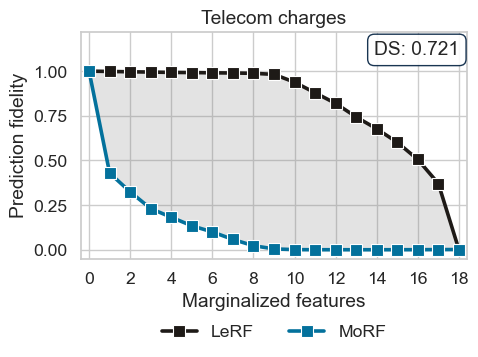

In [13]:
ax = telecom_global.plot(figsize=(5.0, 4.0), title="Telecom charges")
plt.tight_layout()
plt.show()

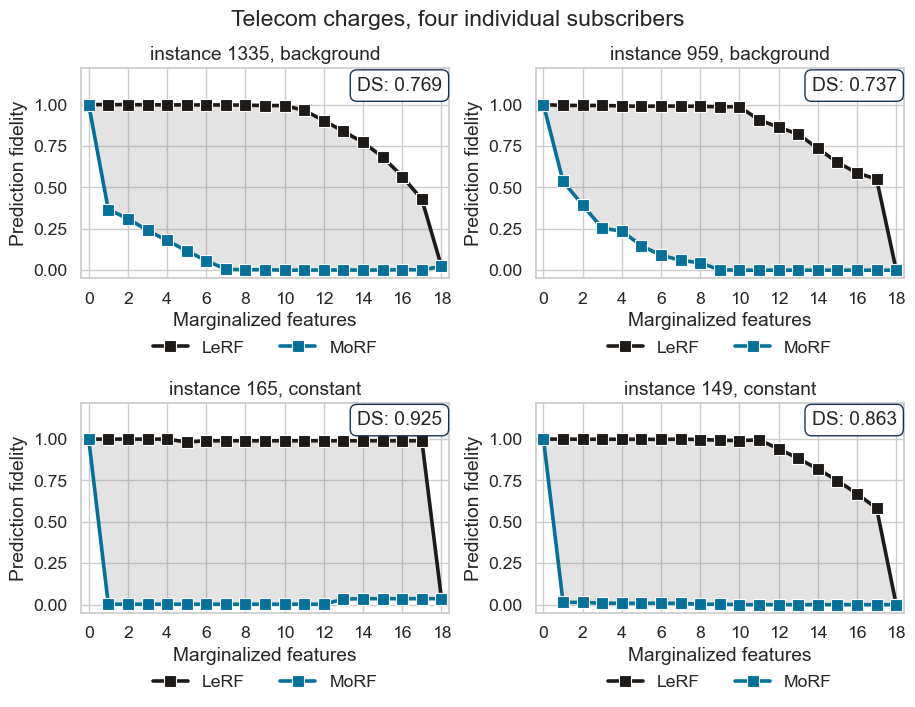

=== instance 1335, background marginalization
SOFI explanation
  task                   regression
  mode                   local
  instances              1
  features               18
  degradation score      0.7689
  area under MoRF        0.1001
  area under LeRF        0.8690
  unperturbed estimate   19.8172
  noise region           from step 10, Contract, SeniorCitizen, Partner, gender, Churn, PaymentMethod, Dependents, PhoneService
  search                 60 iterations, 0 restarts, 59 evaluations, 121 model queries
  ranking                1. InternetService, 2. TechSupport, 3. StreamingTV, 4. StreamingMovies, 5. OnlineSecurity, 6. OnlineBackup, 7. DeviceProtection, 8. MultipleLines, 9. PaperlessBilling, 10. tenure, 11. Contract, 12. SeniorCitizen, 13. Partner, 14. gender, 15. Churn, 16. PaymentMethod, 17. Dependents, 18. PhoneService

=== instance 959, background marginalization
SOFI explanation
  task                   regression
  mode                   local
  instances     

In [14]:
telecom_constant = SOFIExplainer(
    telecom_model, Xt_train_encoded, feature_groups=telecom_groups, marginalization="constant",
    max_iterations=120, patience=40, random_state=RANDOM_STATE, verbose=False,
)

telecom_instances = [
    (1335, "background"),
    (959, "background"),
    (165, "constant"),
    (149, "constant"),
]
telecom_selected = local_explanations(
    telecom_instances,
    {"background": telecom_explainer, "constant": telecom_constant},
    telecom_validation,
)
local_figure(telecom_selected, "Telecom charges, four individual subscribers")

## Example 4: College tuition

Regression over 16 numerical attributes and nothing else, where the target is the tuition charged to students from outside the state. No column requires encoding, so the estimator is handed to the explainer directly, without a pipeline, without an encoder and without a group mapping. This is the simplest possible arrangement.

In [15]:
college = pd.read_csv(SELVA + "College.csv")
college_target = college["Outstate"].astype(float)
college_features = college.drop(columns=["Outstate"]).select_dtypes(include="number")

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    college_features, college_target, test_size=0.25, random_state=RANDOM_STATE
)

college_model = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE)
college_model.fit(Xc_train, yc_train)

print("features", college_features.shape[1], "columns requiring encoding", 0)
print("test coefficient of determination", round(college_model.score(Xc_test, yc_test), 3))

features 16 columns requiring encoding 0
test coefficient of determination 0.811


In [16]:
college_validation, close = select_reliable_instances(
    college_model, Xc_test, yc_test, quantile=0.7, return_mask=True
)
college_validation_target = yc_test[close]

college_explainer = SOFIExplainer(
    college_model, Xc_train, marginalization="background", n_background=10,
    max_iterations=120, patience=40, n_restarts=1,
    random_state=RANDOM_STATE, verbose=False,
)
college_global = college_explainer.explain(college_validation, mode="global")
print(college_global.summary())

SOFI explanation
  task                   regression
  mode                   global
  instances              136
  features               16
  degradation score      0.6405
  area under MoRF        0.1852
  area under LeRF        0.8258
  unperturbed estimate   10254.1412
  noise region           none detected
  search                 120 iterations, 0 restarts, 113 evaluations, 277 model queries
  ranking                1. Expend, 2. Room.Board, 3. Grad.Rate, 4. perc.alumni, 5. F.Undergrad, 6. Apps, 7. S.F.Ratio, 8. P.Undergrad, 9. Personal, 10. Accept, 11. Enroll, 12. Books, 13. Top10perc, 14. PhD, 15. Top25perc, 16. Terminal


C:\Users\20214772\AppData\Local\Temp\ipykernel_13280\1476742091.py:2: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


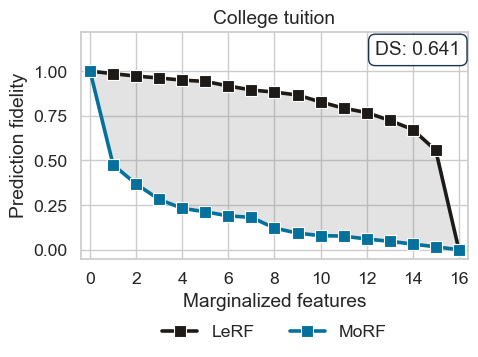

In [17]:
ax = college_global.plot(figsize=(5.0, 4.0), title="College tuition")
plt.tight_layout()
plt.show()

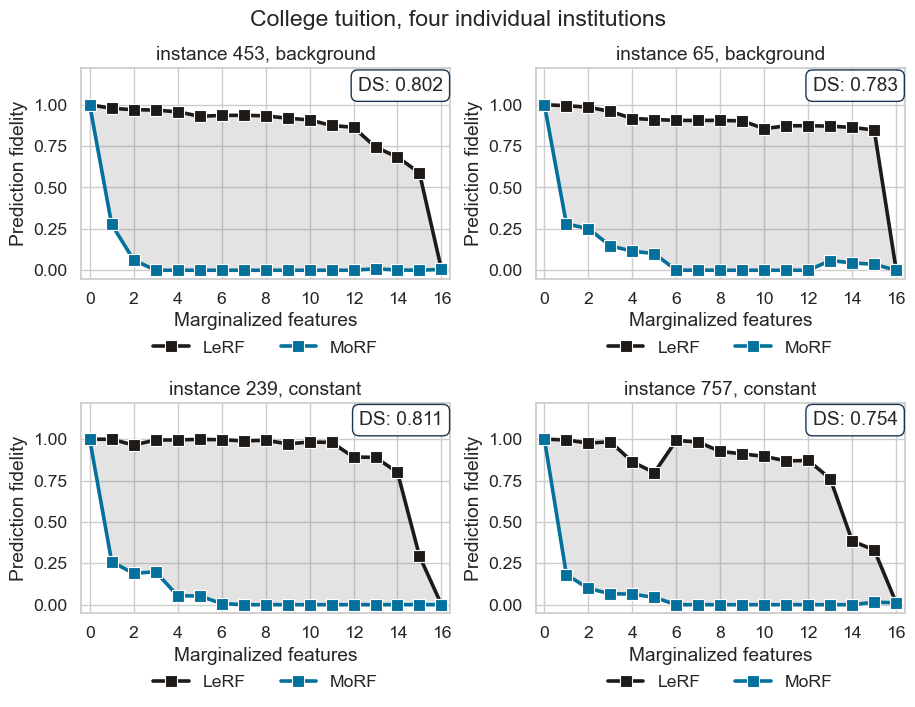

=== instance 453, background marginalization
SOFI explanation
  task                   regression
  mode                   local
  instances              1
  features               16
  degradation score      0.8021
  area under MoRF        0.0533
  area under LeRF        0.8554
  unperturbed estimate   16114.0350
  noise region           none detected
  search                 60 iterations, 0 restarts, 60 evaluations, 123 model queries
  ranking                1. Expend, 2. Room.Board, 3. Grad.Rate, 4. Apps, 5. PhD, 6. Top25perc, 7. Personal, 8. F.Undergrad, 9. Top10perc, 10. Books, 11. Terminal, 12. Accept, 13. perc.alumni, 14. Enroll, 15. S.F.Ratio, 16. P.Undergrad

=== instance 65, background marginalization
SOFI explanation
  task                   regression
  mode                   local
  instances              1
  features               16
  degradation score      0.7831
  area under MoRF        0.0958
  area under LeRF        0.8789
  unperturbed estimate   8421.8700
  noise 

In [18]:
college_constant = SOFIExplainer(
    college_model, Xc_train, marginalization="constant",
    max_iterations=120, patience=40, random_state=RANDOM_STATE, verbose=False,
)

college_instances = [
    (453, "background"),
    (65, "background"),
    (239, "constant"),
    (757, "constant"),
]
college_selected = local_explanations(
    college_instances,
    {"background": college_explainer, "constant": college_constant},
    college_validation,
)
local_figure(college_selected, "College tuition, four individual institutions")